# Setup & Imports

In [22]:
# !pip install pandas numpy matplotlib seaborn plotly statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", 100)
sns.set_context("talk")


# Load the Dataset

In [23]:
CSV_PATH = "../Data/weather_daily_2013_2023.csv"  

df_raw = pd.read_csv(CSV_PATH)
df = df_raw.copy()

df.head(10)

,Date,District,RF,T max,T min,Avg_tem
0,10/1/2013,Colombo,0.0,31.1,25.8,28.45
1,10/2/2013,Colombo,0.0,31.3,27.5,29.40
2,10/3/2013,Colombo,1.6,31.3,27.3,29.30
3,10/4/2013,Colombo,5.8,30.7,25.7,28.20
4,10/5/2013,Colombo,0.3,30.8,24.4,27.60
5,10/6/2013,Colombo,2.5,31.0,25.1,28.05
6,10/7/2013,Colombo,13.2,31.1,24.4,27.75
7,10/8/2013,Colombo,0.0,30.5,24.8,27.65
8,10/9/2013,Colombo,3.4,30.9,27.3,29.10
9,10/10/2013,Colombo,6.2,29.8,26.3,28.05


In [24]:
df.columns

Index(['Date', 'District', 'RF', 'T max ', 'T min', 'Avg_tem'], dtype='object')

In [25]:
df = df.rename(columns={
    'Date': 'date',
    'District': 'district',
    'RF': 'rf',
    'T max ': 't_max',
    'T min': 't_min',
    'Avg_tem': 'avg_temp'
})
print(df.columns)

Index(['date', 'district', 'rf', 't_max', 't_min', 'avg_temp'], dtype='object')


# Check null (missing) values for every column

In [26]:
df.isnull().sum().to_frame('missing_count').assign(
    missing_percent = lambda x: (x['missing_count'] / len(df)) * 100
)

,missing_count,missing_percent
date,0,0.0
district,0,0.0
rf,0,0.0
t_max,0,0.0
t_min,0,0.0
avg_temp,0,0.0


In [27]:
# Parse dates, drop bad rows, sort chronologically
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

In [28]:
df.describe()

,date,rf,t_max,t_min,avg_temp
count,3652,3652.000000,3652.000000,3652.000000,3652.000000
mean,2018-09-30 12:00:00,6.942223,31.211090,25.251177,28.231134
min,2013-10-01 00:00:00,0.000000,25.200000,19.800000,24.050000
25%,2016-03-31 18:00:00,0.000000,30.500000,24.200000,27.550000
50%,2018-09-30 12:00:00,0.100000,31.200000,25.100000,28.250000
75%,2021-03-31 06:00:00,5.500000,32.000000,26.400000,29.000000
max,2023-09-30 00:00:00,256.900000,35.900000,29.400000,31.300000
std,NaN,16.468035,1.255083,1.514078,1.026992


In [29]:
df.nunique()

date        3652
district       1
rf           473
t_max         99
t_min         92
avg_temp     130
dtype: int64

In [30]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nDate range:", df['date'].min(), "→", df['date'].max())

Shape: (3652, 6)

Data types:
 date        datetime64[ns]
district            object
rf                 float64
t_max              float64
t_min              float64
avg_temp           float64
dtype: object

Date range: 2013-10-01 00:00:00 → 2023-09-30 00:00:00


# Check for duplicate dates

In [31]:
dup_count = df['date'].duplicated().sum()
print(dup_count)

0


In [32]:
num_cols = [c for c in ['rf','t_max','t_min','avg_temp'] if c in df.columns]
print(num_cols)

['rf', 't_max', 't_min', 'avg_temp']


In [33]:
# Coerce numerics
for c in ['rf','t_max','t_min','avg_temp']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Sanity checks: t_min <= avg_temp <= t_max (flag violations)
if all(col in df.columns for col in ['t_min','avg_temp','t_max']):
    bad_temp = df[(df['t_min'] > df['avg_temp']) | (df['avg_temp'] > df['t_max'])]
    print("Temp ordering violations:", bad_temp.shape[0])

# Basic outlier flags (not removing yet)
q = df[num_cols].quantile([0.01,0.99])
q


Temp ordering violations: 0


,rf,t_max,t_min,avg_temp
0.01,0.000,27.251,21.7,25.45
0.99,78.278,34.200,28.4,30.40


# Add Calendar Features

In [34]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dayofyear'] = df['date'].dt.dayofyear
df['weekday'] = df['date'].dt.weekday
df.sample(3)

,date,district,rf,t_max,t_min,avg_temp,year,month,dayofyear,weekday
538,2015-03-23,Colombo,0.0,31.5,25.4,28.45,2015,3,82,0
2473,2020-07-09,Colombo,0.1,31.1,27.7,29.40,2020,7,191,3
2226,2019-11-05,Colombo,0.4,31.6,24.1,27.85,2019,11,309,1


# Univariate Distributions

Share of dry days (RF=0): 49.53%


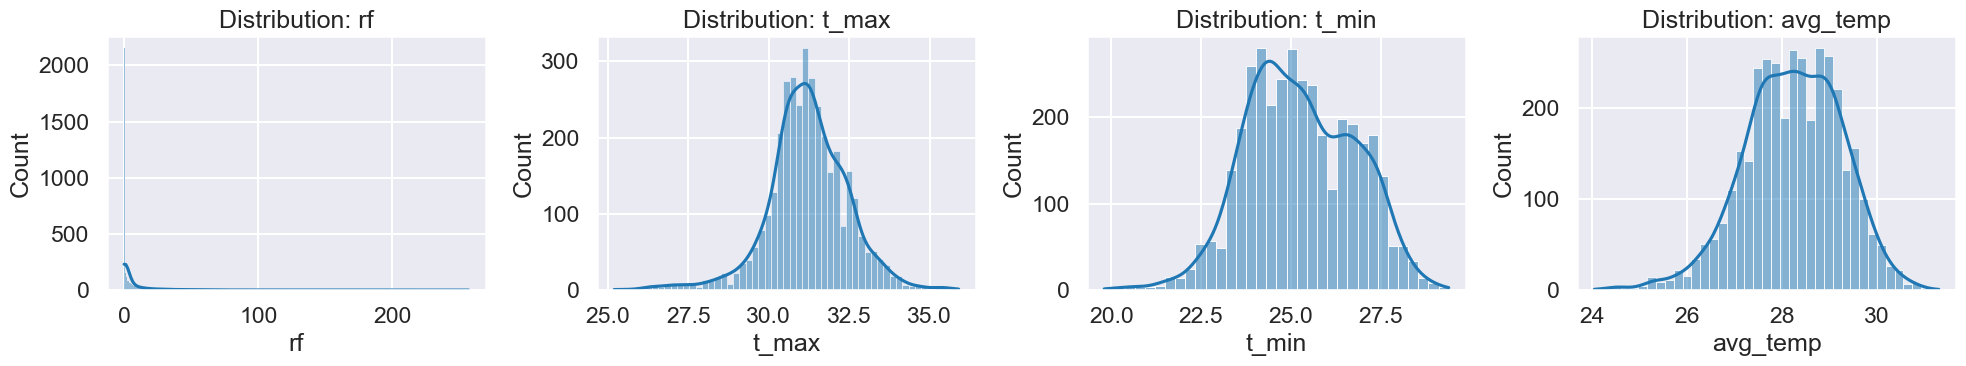

In [35]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution: {c}")
plt.tight_layout()

# Rainfall is skewed: show zeros vs non-zeros
if 'rf' in df.columns:
    zero_share = (df['rf']<=0).mean()
    print(f"Share of dry days (RF=0): {zero_share:.2%}")


# Time Series Overview

In [36]:
import plotly.graph_objects as go

fig = go.Figure()

# Rainfall
fig.add_trace(go.Scatter(x=df['date'], y=df['rf'], mode='lines', name='Rainfall (mm)'))

fig.update_layout(
    title='Daily Rainfall and Temperature Trends',
    xaxis_title='Date',
    yaxis_title='Value',
    height=500
)
fig.show()

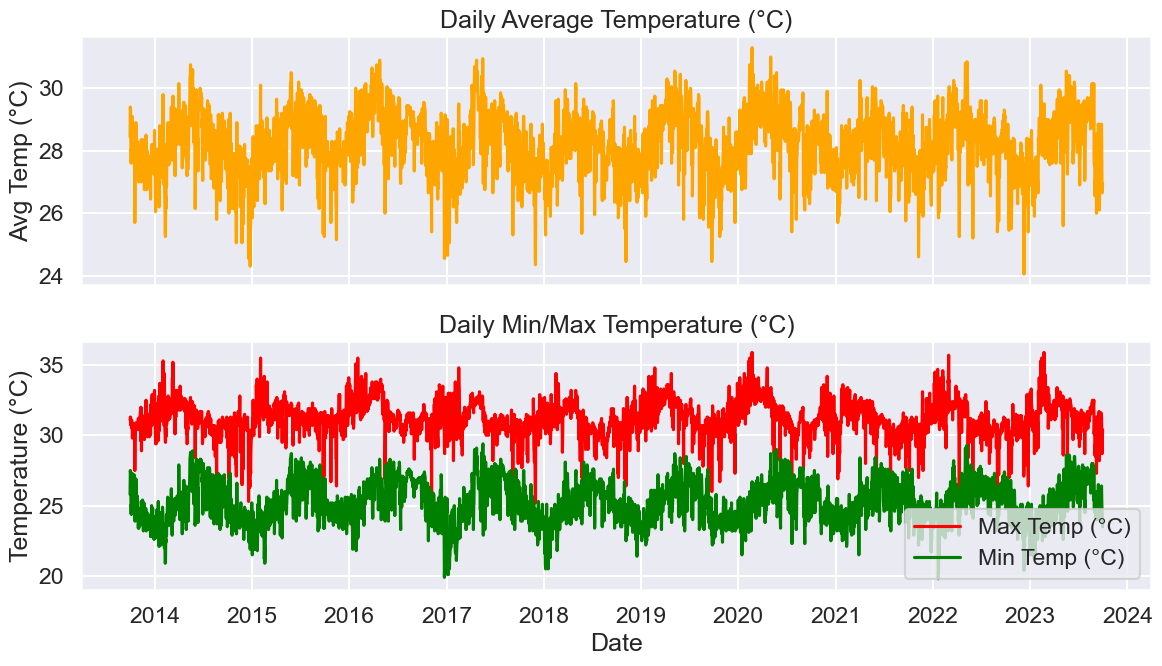

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# 🌡 Daily Average Temperature
if 'avg_temp' in df.columns:
    ax[0].plot(df['date'], df['avg_temp'], color='orange')
    ax[0].set_title('Daily Average Temperature (°C)')
    ax[0].set_ylabel('Avg Temp (°C)')

# 🔺🔻 Daily Min/Max Temperature
if 't_max' in df.columns and 't_min' in df.columns:
    ax[1].plot(df['date'], df['t_max'], label='Max Temp (°C)', color='red')
    ax[1].plot(df['date'], df['t_min'], label='Min Temp (°C)', color='green')
    ax[1].legend()
    ax[1].set_title('Daily Min/Max Temperature (°C)')
    ax[1].set_ylabel('Temperature (°C)')

plt.xlabel('Date')
plt.tight_layout()
plt.show()


Yearly trend: 


,year,rf,t_max,t_min,avg_temp
0,2013,4.101087,30.858696,24.509783,27.684239
1,2014,7.219178,30.984932,25.107123,28.046027
2,2015,8.076712,31.386027,25.102740,28.244384
3,2016,6.440164,31.609563,25.697541,28.653552
4,2017,6.249863,31.021096,25.345753,28.183425
5,2018,7.019726,30.894247,24.936986,27.915616
6,2019,7.848767,31.339452,25.060822,28.200137
7,2020,5.693989,31.588525,25.556284,28.572404
8,2021,7.824932,30.928493,25.166027,28.047260
9,2022,6.548219,30.980548,25.330137,28.155342


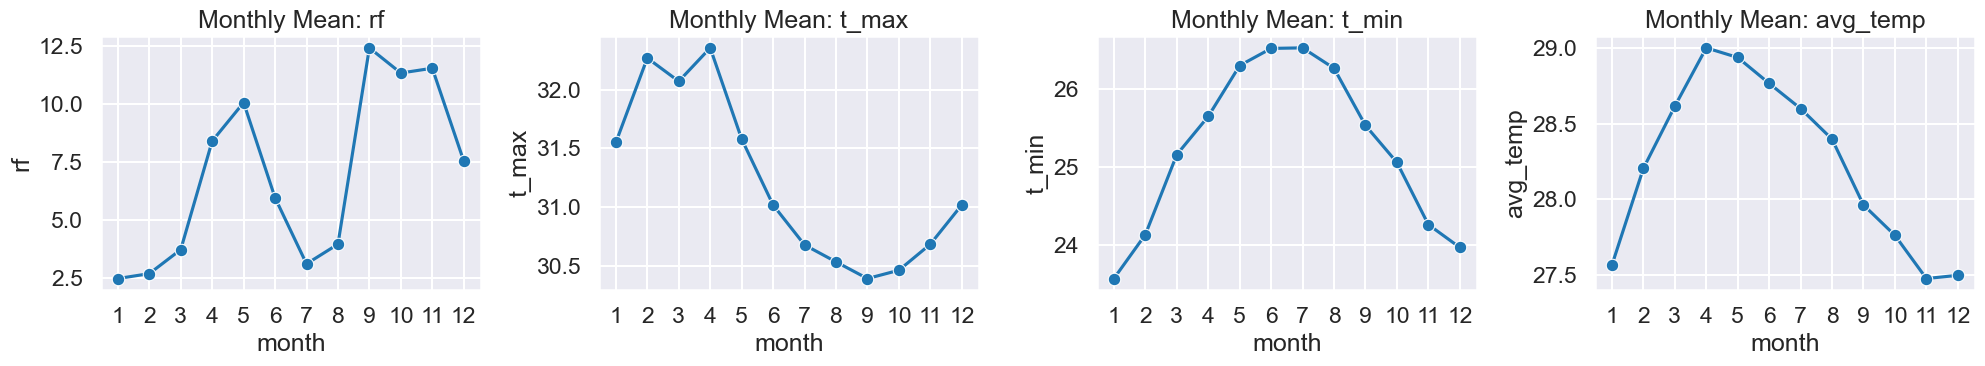

In [38]:
# Monthly averages (all years)
monthly = df.groupby('month')[num_cols].mean().reset_index()

fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols),4))
for i, c in enumerate(num_cols):
    sns.lineplot(data=monthly, x='month', y=c, marker='o', ax=axes[i])
    axes[i].set_title(f"Monthly Mean: {c}")
    axes[i].set_xticks(range(1,13))
plt.tight_layout()

# Yearly trend
print('Yearly trend: ')
yearly = df.groupby('year')[num_cols].mean().reset_index()
display(yearly)


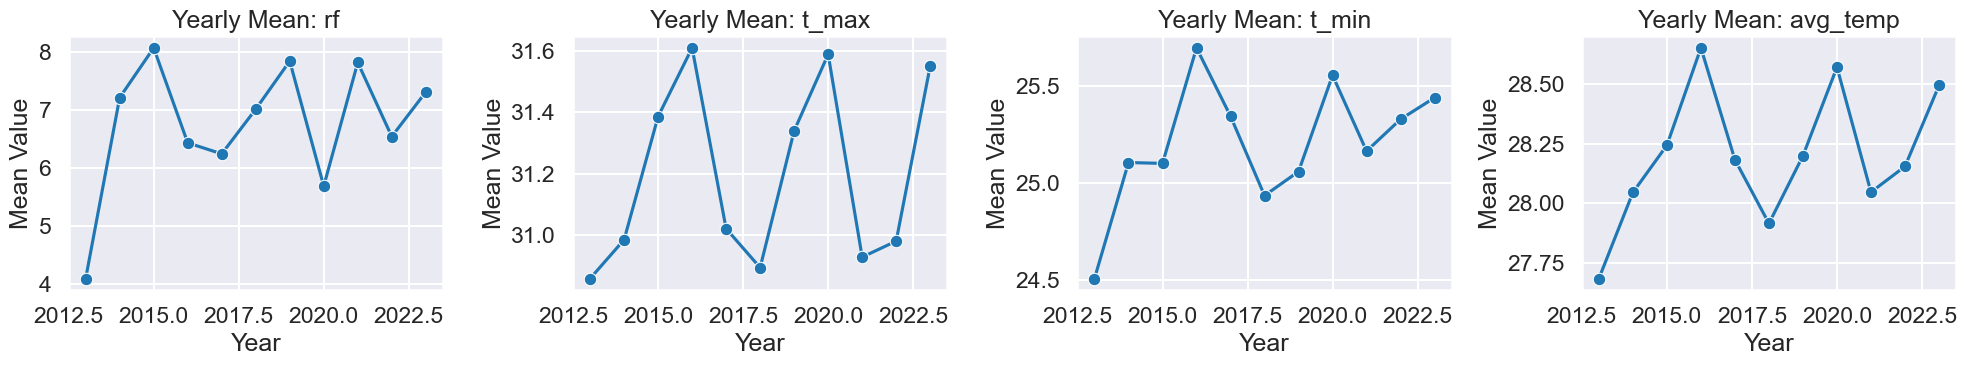

In [39]:
# Group by year and calculate mean
yearly = df.groupby('year')[num_cols].mean().reset_index()

# Plot each variable’s yearly mean
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for i, c in enumerate(num_cols):
    sns.lineplot(data=yearly, x='year', y=c, marker='o', ax=axes[i])
    axes[i].set_title(f"Yearly Mean: {c}")
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Mean Value')

plt.tight_layout()
plt.show()

# Correlations & Pairwise Relationships

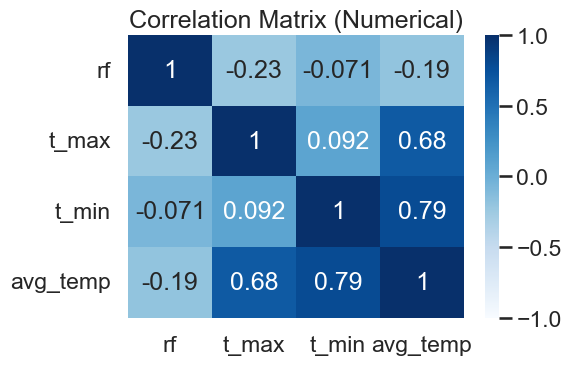

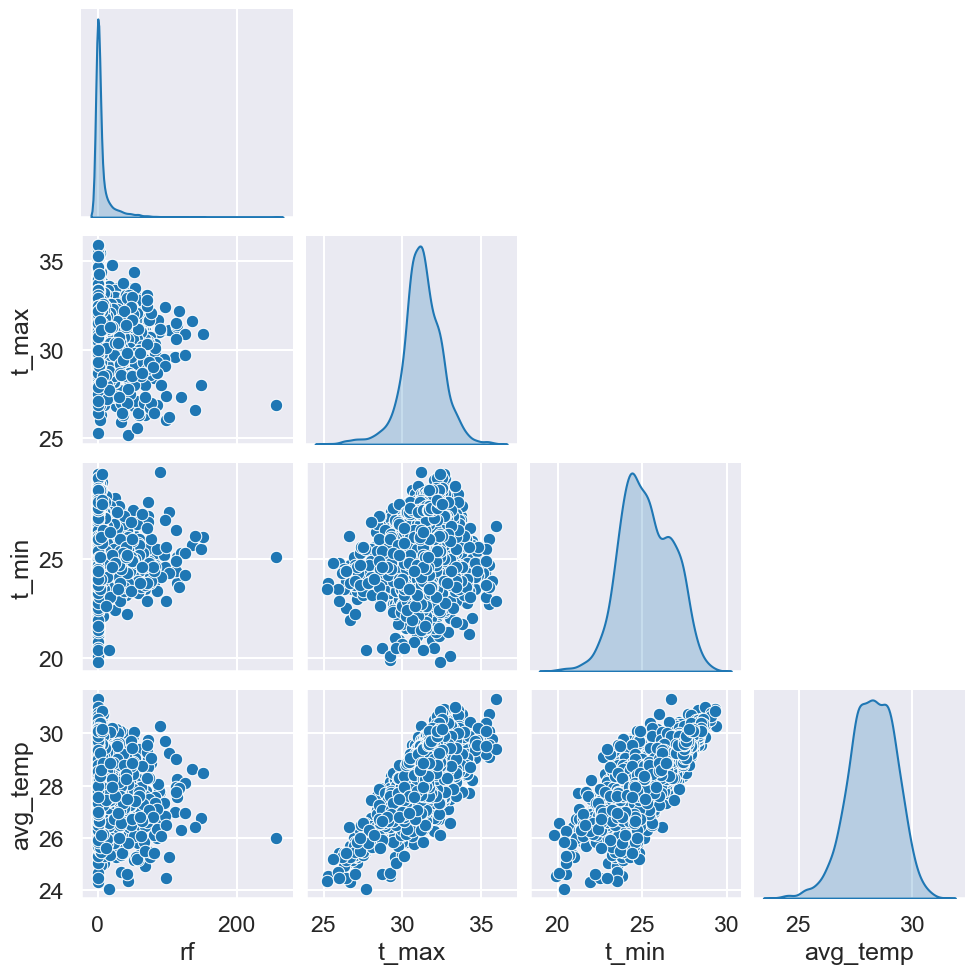

In [40]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numerical)"); plt.tight_layout()

sns.pairplot(df[num_cols], corner=True, diag_kind='kde')
plt.show()


In [41]:
path = "../Data/weather_daily_2013_2023_after.csv"  # Windows example
# path = "/Users/Yeran/Desktop/RainPrediction/data/rain_data.csv"  # macOS/Linux example

# Save DataFrame to CSV
df.to_csv(path, index=False)

print(f"CSV file saved successfully at: {path}")

CSV file saved successfully at: ../Data/weather_daily_2013_2023_after.csv
